# Sample-level OOD analysis

Top row: full-dataset NER, NCE and ECUAS per model. Remaining rows, for each of N samples: the CIFAR-10 image, each model's predicted probability distribution, and per-sample metrics (correctness, NCE, CUAS).

In [51]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from ecuas.classification import ClassificationCrossEntropy, ClassificationECUAS, ClassificationErrorRate
from torchvision.datasets import CIFAR10

In [52]:
MODEL_NAMES = ["resnet20", "vgg19_bn", "repvgg_a2"]
DATASET_NAME = "cifar10"
N_SAMPLES = 5

DATA_DIR = Path("../data")
OUTPUTS_ROOT = Path("../outputs/ood_analysis")

In [53]:
# Unnormalized scores (logits), one per model, indexed like the CIFAR-10 test set.
scores_per_model = {
    model_name: pd.read_csv(
        OUTPUTS_ROOT / model_name / DATASET_NAME / "scores_ID.csv", header=0, index_col=0
    )
    for model_name in MODEL_NAMES
}
# Labels are the same test set for every model.
labels = pd.read_csv(
    OUTPUTS_ROOT / MODEL_NAMES[0] / DATASET_NAME / "labels_ID.csv", header=0, index_col=0
)

# torch_uncertainty's CIFAR10DataModule test loader wraps this dataset with
# shuffle=False, so row i here matches row i of scores/labels.
cifar10_test = CIFAR10(root=DATA_DIR, train=False, download=False)

for model_name, model_scores in scores_per_model.items():
    assert len(model_scores) == len(labels) == len(cifar10_test), model_name

In [58]:
def correctness(scores: np.ndarray, labels: pd.DataFrame, idx: int) -> float | None:
    return scores[idx].argmax() == labels.iloc[idx, 0]


def compute_dataset_ner(scores: np.ndarray, labels: pd.DataFrame) -> float:
    metric = ClassificationErrorRate(reduction="mean")
    scores_tensor = torch.from_numpy(scores)
    labels_tensor = torch.from_numpy(labels.to_numpy(dtype=np.int64).flatten())
    metric.update(scores_tensor, labels_tensor)
    return metric.compute().item()


def compute_nce(scores: np.ndarray, labels: pd.DataFrame, idx: int) -> float | None:
    metric = ClassificationCrossEntropy(reduction="none")
    scores_tensor = torch.from_numpy(scores)
    labels_tensor = torch.from_numpy(labels.to_numpy(dtype=np.int64).flatten())
    metric.update(scores_tensor, labels_tensor)
    nce_value = metric.compute()[idx].item()
    return nce_value


def compute_dataset_nce(scores: np.ndarray, labels: pd.DataFrame) -> float:
    metric = ClassificationCrossEntropy(reduction="mean")
    scores_tensor = torch.from_numpy(scores)
    labels_tensor = torch.from_numpy(labels.to_numpy(dtype=np.int64).flatten())
    metric.update(scores_tensor, labels_tensor)
    nce_value = metric.compute().item()
    return nce_value


def compute_cuas(scores: np.ndarray, labels: pd.DataFrame, idx: int) -> float | None:
    metric = ClassificationECUAS(reduction="none")
    scores_tensor = torch.from_numpy(scores)
    labels_tensor = torch.from_numpy(labels.to_numpy(dtype=np.int64).flatten())
    metric.update(scores_tensor, labels_tensor)
    cuas_value = metric.compute()[idx].item()
    return cuas_value


def compute_dataset_ecuas(scores: np.ndarray, labels: pd.DataFrame) -> float:
    metric = ClassificationECUAS(reduction="mean")
    scores_tensor = torch.from_numpy(scores)
    labels_tensor = torch.from_numpy(labels.to_numpy(dtype=np.int64).flatten())
    metric.update(scores_tensor, labels_tensor)
    cuas_value = metric.compute().item()
    return cuas_value


SAMPLE_METRICS = {
    "Correct": correctness,
    "Normalized\nlogloss": compute_nce,
    "CUAS": compute_cuas,
}

In [59]:
CIFAR10_CLASSES = cifar10_test.classes


def plot_sample_level_analysis(indices):
    n = len(indices)
    n_rows = n + 1  # +1 for the full-dataset summary row
    n_cols = 1 + 2 * len(MODEL_NAMES)  # image, then (probs, metrics) per model
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.6 * n_cols, 2.5 * n_rows))
    if n_rows == 1:
        axes = axes[None, :]

    # Row 0: full-dataset metrics per model.
    axes[0, 0].axis("off")
    axes[0, 0].text(
        0.05, 0.5, f"Full test set\n(n={len(labels)})", va="center", fontsize=10, fontweight="bold"
    )
    for model_i, model_name in enumerate(MODEL_NAMES):
        prob_col = 1 + 2 * model_i
        metrics_col = prob_col + 1

        axes[0, prob_col].axis("off")
        axes[0, prob_col].set_title(model_name, fontsize=10, fontweight="bold")

        scores_matrix = scores_per_model[model_name].to_numpy(dtype=np.float32).copy()
        dataset_metrics = {
            "NER": compute_dataset_ner(scores_matrix, labels),
            "NCE": compute_dataset_nce(scores_matrix, labels),
            "ECUAS": compute_dataset_ecuas(scores_matrix, labels),
        }
        ax_metrics = axes[0, metrics_col]
        ax_metrics.axis("off")
        text_lines = [f"{name}: {value:.4f}" for name, value in dataset_metrics.items()]
        ax_metrics.text(0.05, 0.5, "\n".join(text_lines), va="center", fontsize=9)

    # Remaining rows: one per sample.
    for row_offset, idx in enumerate(indices):
        row = row_offset + 1
        image, _ = cifar10_test[idx]
        label = int(labels.loc[idx, "label"])

        # Column 0: image
        ax_img = axes[row, 0]
        ax_img.imshow(image)
        ax_img.set_title(f"idx={idx} | label={CIFAR10_CLASSES[label]}", fontsize=9)
        ax_img.axis("off")

        # Per model: probability distribution (softmax of the unnormalized scores) as
        # a horizontal bar chart, immediately followed by that model's metrics.
        for model_i, model_name in enumerate(MODEL_NAMES):
            prob_col = 1 + 2 * model_i
            metrics_col = prob_col + 1

            scores_matrix = scores_per_model[model_name].to_numpy(dtype=np.float32).copy()
            scores_row = scores_matrix[idx]
            probs = torch.softmax(torch.from_numpy(scores_row), dim=0).numpy()
            pred = int(probs.argmax())

            ax_prob = axes[row, prob_col]
            bar_colors = [
                "tab:green" if c == label else "tab:blue" for c in range(len(CIFAR10_CLASSES))
            ]
            ax_prob.barh(range(len(CIFAR10_CLASSES)), probs, color=bar_colors)
            ax_prob.set_yticks(range(len(CIFAR10_CLASSES)))
            ax_prob.set_yticklabels(CIFAR10_CLASSES, fontsize=6)
            ax_prob.invert_yaxis()
            ax_prob.set_xlim(0, 1)
            ax_prob.set_title(
                f"pred={CIFAR10_CLASSES[pred]} (p={probs[pred]:.2f})", fontsize=9
            )

            ax_metrics = axes[row, metrics_col]
            ax_metrics.axis("off")
            text_lines = []
            for metric_name, metric_fn in SAMPLE_METRICS.items():
                value = metric_fn(scores_matrix, labels, idx)
                if isinstance(value, float):
                    text_lines.append(f"{metric_name}: {value:.4f}")
                else:
                    text_lines.append(f"{metric_name}: {value}")
            ax_metrics.text(0.05, 0.5, "\n".join(text_lines), va="center", fontsize=10)

    fig.tight_layout()
    return fig

In [60]:
def get_misclassified_indices(n_samples: int) -> list[int]:
    """Indices of samples misclassified by at least one of MODEL_NAMES, in index order."""
    true_labels = labels["label"].to_numpy()
    misclassified = np.zeros(len(true_labels), dtype=bool)
    for model_name in MODEL_NAMES:
        logits = scores_per_model[model_name].to_numpy(dtype=np.float32)
        preds = logits.argmax(axis=1)
        misclassified |= preds != true_labels

    return np.flatnonzero(misclassified)[:n_samples].tolist()

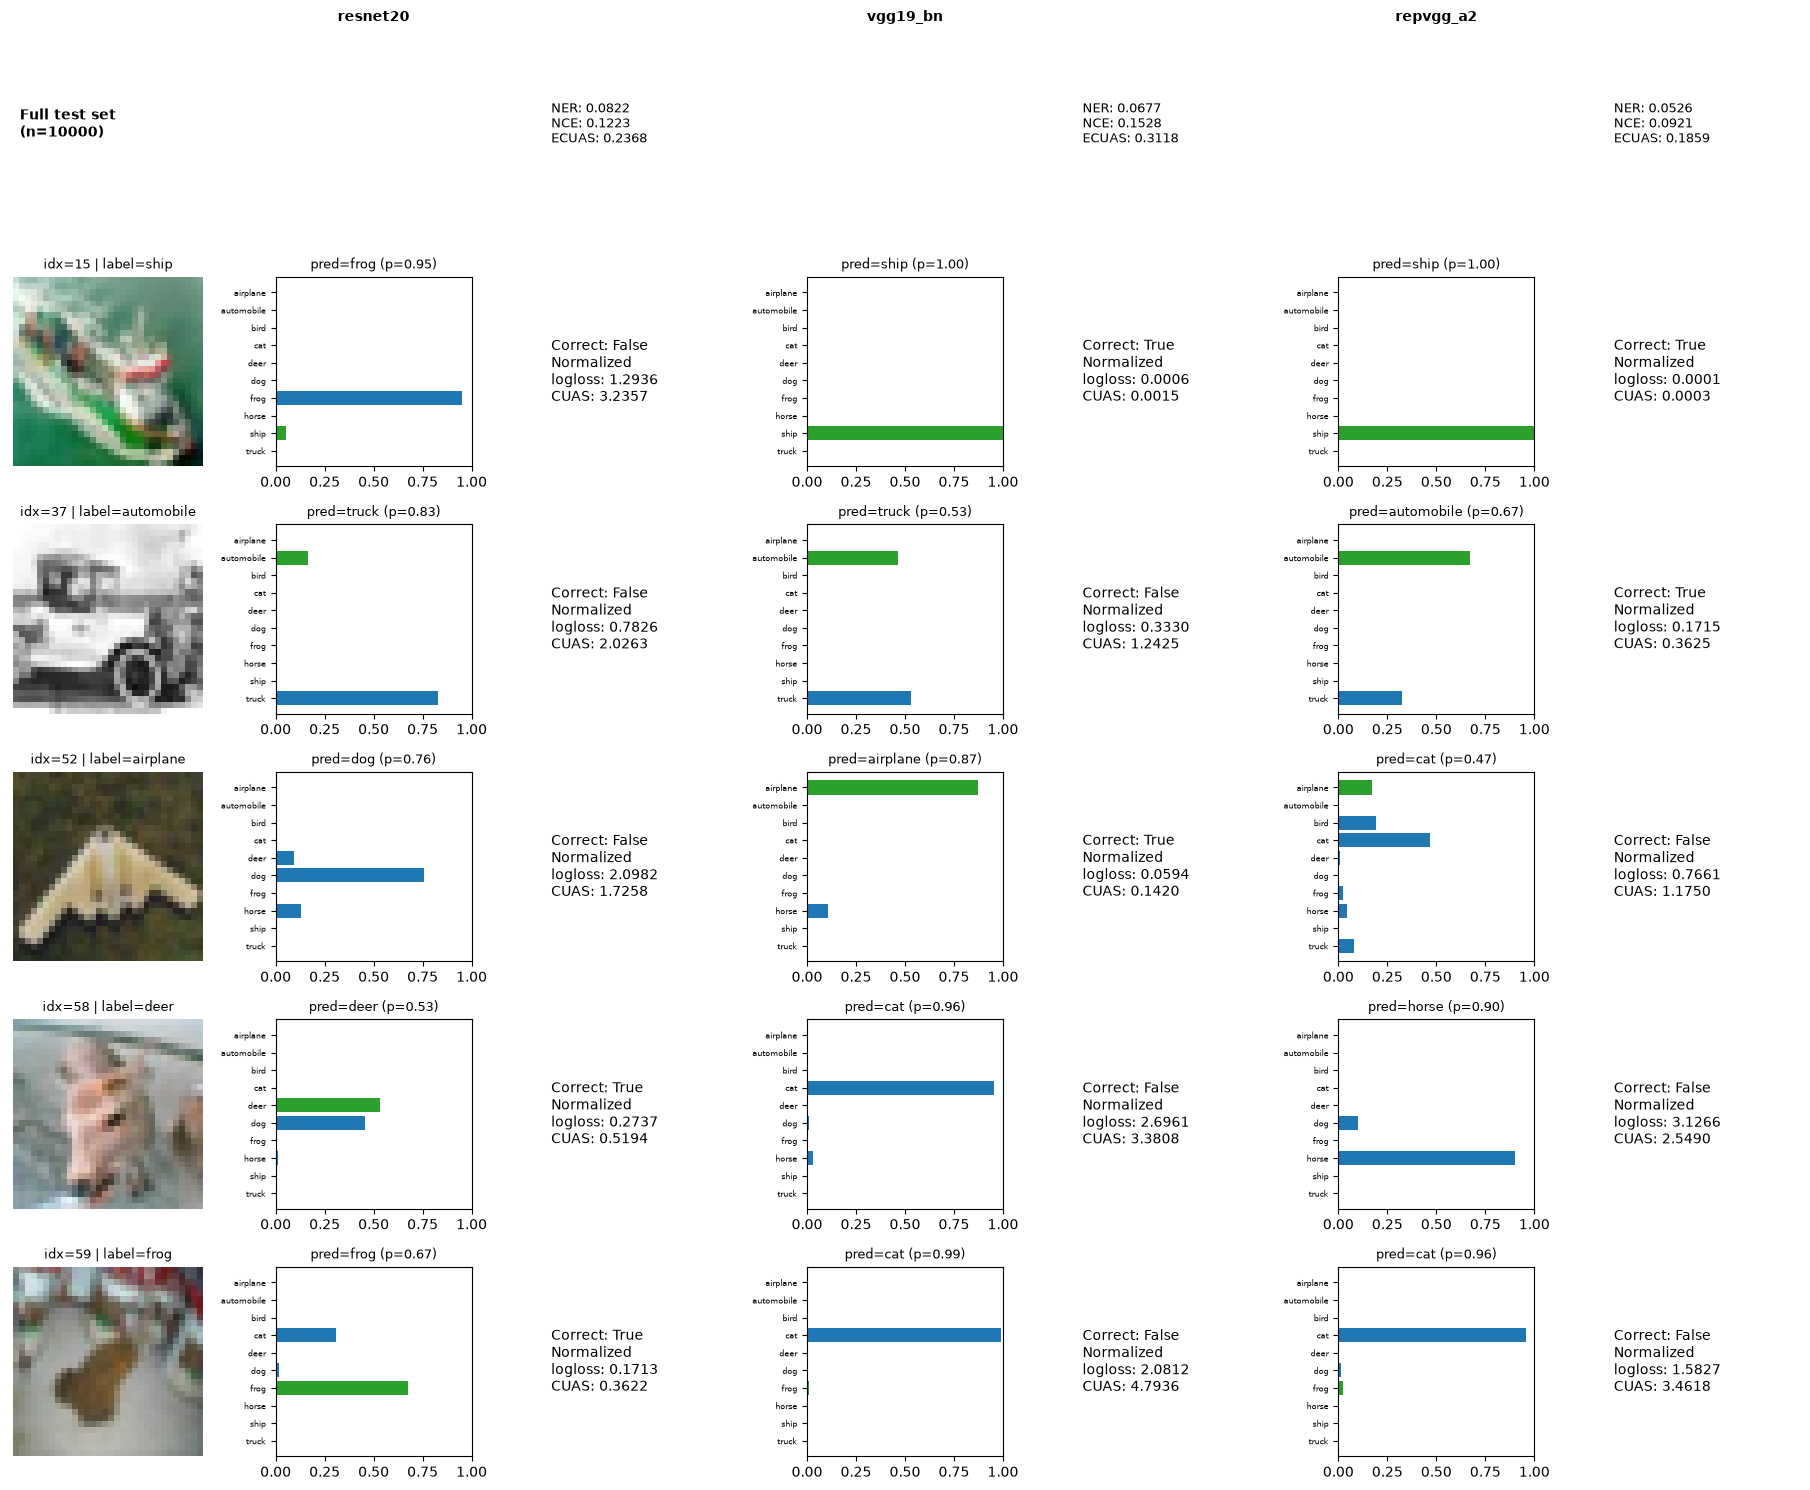

In [61]:
indices = get_misclassified_indices(N_SAMPLES)
fig = plot_sample_level_analysis(indices=indices)
plt.show()